                                           Statement       Web  Category  \
0  Heritage Conservation Committee approves const...  THEPRINT  POLITICS   
1                        Neta Profiling  Party Wise    FACTLY  ELECTION   
2                 Quotable Quotes  The best of 2011    FACTLY  POLITICS   
3        Open Letter from Anna Hazare to all Indians    FACTLY  POLITICS   
4               Kaun Banega Cr000,000,000,000repati!    FACTLY  COVID-19   

  Label Month-Year  Year  
0  TRUE     Aug-04  2004  
1  TRUE     Dec-11  2011  
2  TRUE     Dec-11  2011  
3  TRUE     Oct-11  2011  
4  TRUE     Jul-11  2011  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38081 entries, 0 to 38080
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Statement   38081 non-null  object
 1   Web         38081 non-null  object
 2   Category    38081 non-null  object
 3   Label       38081 non-null  object
 4   Month-Year  38081 non-null  

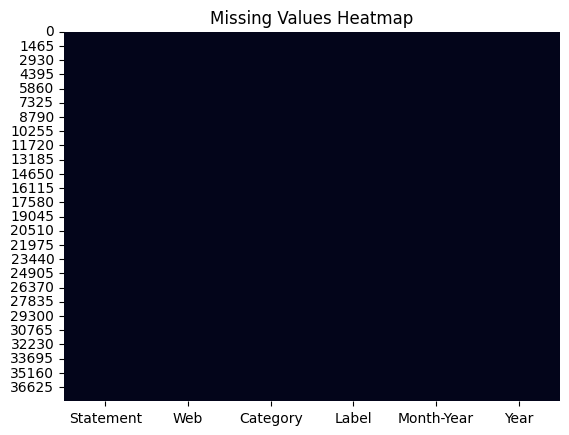

Label
TRUE    37789
Fake      292
Name: count, dtype: int64
Index(['Statement', 'Web', 'Category', 'Label', 'Month-Year', 'Year'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38081 entries, 0 to 38080
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Statement   38081 non-null  object
 1   Web         38081 non-null  object
 2   Category    38081 non-null  object
 3   Label       38081 non-null  object
 4   Month-Year  38081 non-null  object
 5   Year        38081 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 1.7+ MB


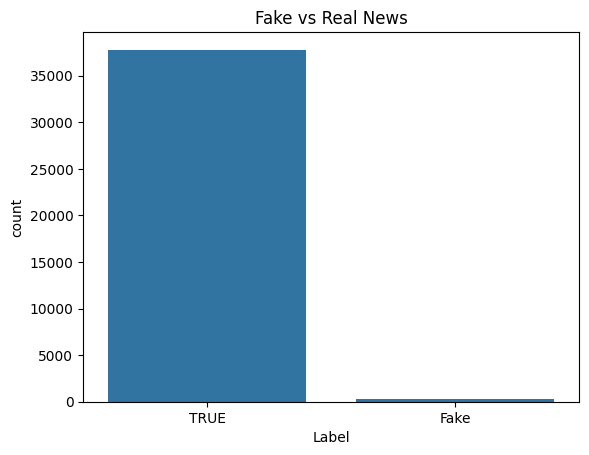

In [ ]:
# -*- coding: utf-8 -*-
"""Untitled34.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1y8ClwEwIHH6WPTohCQRsSY3-qdmrrbRT
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/final_dataset.csv")
print(df.head())
print(df.info())

df.isnull().sum()

df.isnull().values.any()

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

print(df['Label'].value_counts())

print(df.columns)

df.info()
df.describe()

df.isnull().sum()

sns.countplot(x='Label', data=df)
plt.title("Fake vs Real News")
plt.show()

In [ ]:
# Clean Label column properly
df['Label'] = df['Label'].str.strip()

# Convert to consistent lowercase
df['Label'] = df['Label'].str.lower()

print("Unique labels:", df['Label'].unique())

# Correct mapping
y = df['Label'].map({'fake': 0, 'true': 1})

print("Missing in y:", y.isnull().sum())
print("Class distribution:\n", y.value_counts())

Unique labels: ['fake']
Missing in y: 0
Class distribution:
 Label
0    292
Name: count, dtype: int64


In [ ]:
print(df['Label'].unique())

['Fake']


In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# 1️⃣ Load Dataset
# -----------------------------
df = pd.read_csv("final_dataset.csv")

# -----------------------------
# 2️⃣ Fix Label Column
# -----------------------------
# Make labels clean and consistent
df['Label'] = df['Label'].str.strip().str.lower()

print("Original Label Distribution:\n", df['Label'].value_counts())

# Map TRUE and Fake properly
df['Label'] = df['Label'].map({
    'fake': 0,
    'true': 1
})

# Remove any incorrect rows
df = df.dropna(subset=['Label'])

# -----------------------------
# 3️⃣ Clean Text
# -----------------------------
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

df['clean_text'] = df['Statement'].apply(clean_text)

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

df['clean_text'] = df['clean_text'].apply(remove_stopwords)

# -----------------------------
# 4️⃣ TF-IDF Vectorization
# -----------------------------
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_text'])
y = df['Label']

# -----------------------------
# 5️⃣ Train-Test Split (VERY IMPORTANT)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps both True and Fake in train
)

print("Training Distribution:\n", y_train.value_counts())

# -----------------------------
# 6️⃣ Train Model
# -----------------------------
model = LogisticRegression(max_iter=1000, class_weight='balanced', C=0.5)
model.fit(X_train, y_train)
print("Model Trained Successfully ✅")

# -----------------------------
# 7️⃣ Evaluate
# -----------------------------
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
from sklearn.svm import LinearSVC

model = LinearSVC(class_weight='balanced')
model.fit(X_train, y_train)

Original Label Distribution:
 Label
true    37789
fake      292
Name: count, dtype: int64


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Training Distribution:
 Label
1    30230
0      234
Name: count, dtype: int64
Model Trained Successfully ✅
Accuracy: 0.9930418800052514

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.74      0.62        58
           1       1.00      0.99      1.00      7559

    accuracy                           0.99      7617
   macro avg       0.76      0.87      0.81      7617
weighted avg       0.99      0.99      0.99      7617



LinearSVC(class_weight='balanced')

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))


 Logistic Regression
Accuracy: 0.9961927267953262

 SVM
Accuracy: 0.9976368649074439

 Decision Tree
Accuracy: 0.9957988709465669

 KNN
Accuracy: 0.995142444531968


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.74      0.62        58
           1       1.00      0.99      1.00      7559

    accuracy                           0.99      7617
   macro avg       0.76      0.87      0.81      7617
weighted avg       0.99      0.99      0.99      7617



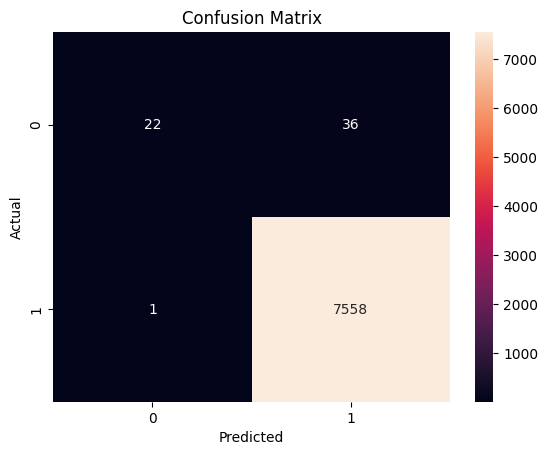

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

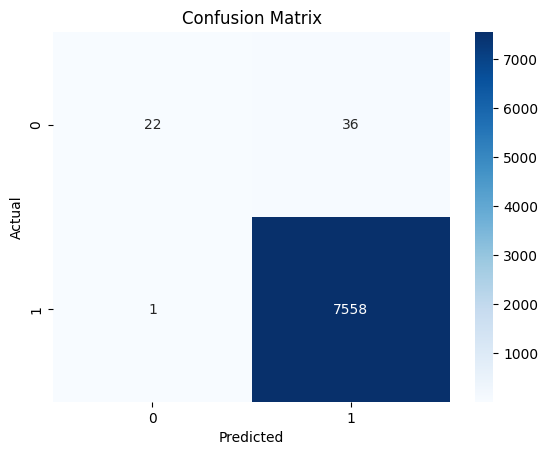

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
def predict_news(text):
    text = clean_text(text)
    text = remove_stopwords(text)
    vector = vectorizer.transform([text])

    prediction = model.predict(vector)

    if prediction[0] == 1:
        print("This News is TRUE")
    else:
        print("This News is FAKE")

# Call the function
predict_news("Government announces new education reform policy")

This News is TRUE


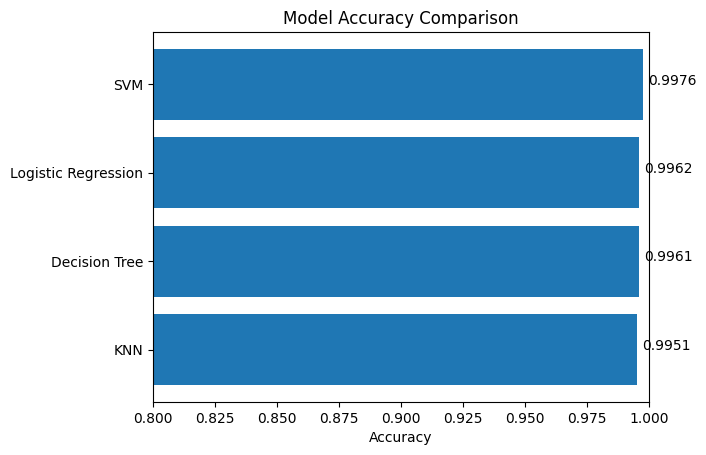

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy_results[name] = accuracy_score(y_test, y_pred)

# Sort results (best on top)
sorted_results = dict(sorted(accuracy_results.items(), key=lambda x: x[1]))

plt.figure()
bars = plt.barh(list(sorted_results.keys()), list(sorted_results.values()))

plt.xlim(0.80, 1.0)   # adjust if your accuracy is between 0.80–1.0
plt.xlabel("Accuracy")
plt.title("Model Accuracy Comparison")

# Write values on bars
for i, v in enumerate(sorted_results.values()):
    plt.text(v + 0.002, i, f"{v:.4f}")

plt.show()

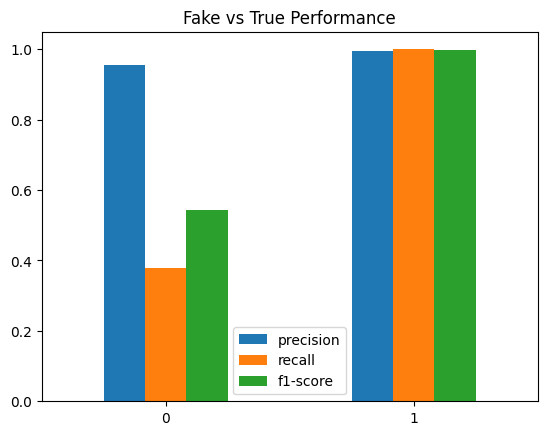

In [ ]:
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Keep only class 0 and 1
report_df = report_df.loc[['0', '1']]

report_df[['precision','recall','f1-score']].plot(kind='bar')
plt.title("Fake vs True Performance")
plt.xticks(rotation=0)
plt.show()